# Eksperimen 6: Visualisasi Biomechanical Attention — Fase Serius

Notebook ini menggabungkan **bobot atensi mentah dari model** (sigmoid BSP) dengan
**Exercise-Specific Spatial Prior Mask** (aturan biomekanika murni) untuk menghasilkan
visualisasi attention yang bermakna dan dapat diinterpretasi secara ilmiah.

**Formula Final Attention:**

$$\text{final\_attention}_i = \text{raw\_attention}_i \times \text{prior\_mask}_i$$

Lalu di-**Min-Max Normalize** agar kontras warna penuh.

**Struktur Notebook:**

| Cell | Isi |
|---|---|
| **1. Setup & Load Model** | Import library, muat `best_model.pth`, ekstrak `raw_attention` |
| **2. Fungsi Visualisasi** | `render_biomechanical_attention()` — glow + warna adaptif |
| **3. Eksekusi SQUAT** | Prior mask: Pinggul (23,24) & Lutut (25,26) = 1.0 |
| **4. Eksekusi DEADLIFT** | Prior mask: Bahu (11,12), Pinggul (23,24) & Lutut (25,26) = 1.0 |
| **5. Eksekusi BENCH PRESS** | Prior mask: Bahu (11,12), Siku (13,14) & Pergelangan Tangan (15,16) = 1.0 |

**Skema warna (berdasarkan `final_attention_normalized`):**

| Nilai Ternormalisasi | Warna | Radius | Teks |
|---|---|---|---|
| **> 0.4** (kritis) | 🔴 Merah Terang + Glow | Besar (16px) | nilai raw asli (e.g. `0.76`) — CYAN |
| **≤ 0.4** (non-kritis) | ⚫ Abu-abu Redup | Kecil (5px) | nilai raw asli (e.g. `0.68`) — Cyan redup |


## 1. Setup & Load Model


In [ ]:

# ============================================================
# 1. Setup & Load Model
#    - Import semua library
#    - Muat checkpoint model (strict=False agar model ablasi tidak crash)
#    - Ekstrak raw_attention dengan fallback seragam untuk ablasi/baseline
# ============================================================
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
import sys

import pandas as pd
import torch

# ── Setup sys.path ─────────────────────────────────────────────────────────────
ROOT_DIR = Path("..").resolve()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.models.model_3dcnn import AttentiveSkel3D

# ── Inisialisasi MediaPipe ─────────────────────────────────────────────────────
mp_pose = mp.solutions.pose

# ── Muat Model ─────────────────────────────────────────────────────────────────
MODEL_PATH = Path("../models/saved_models/AttentiveSkel3D_Final.pth")
model = AttentiveSkel3D(num_classes=2)

print(f"Memuat checkpoint dari : {MODEL_PATH}")
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"File model tidak ditemukan: {MODEL_PATH}")

checkpoint = torch.load(str(MODEL_PATH), map_location="cpu")
if isinstance(checkpoint, dict):
    if "model_state_dict" in checkpoint:
        # KRUSIAL: strict=False agar model ablasi (yang tidak memiliki layer
        # biomechanical_spatial_prior) tidak crash dengan "Missing keys".
        model.load_state_dict(checkpoint["model_state_dict"], strict=False)
        print("  Format checkpoint   : {'model_state_dict': ...}")
    elif "state_dict" in checkpoint:
        model.load_state_dict(checkpoint["state_dict"], strict=False)
        print("  Format checkpoint   : {'state_dict': ...}")
    else:
        model.load_state_dict(checkpoint, strict=False)
        print("  Format checkpoint   : state_dict langsung (dict)")
else:
    model.load_state_dict(checkpoint, strict=False)
    print("  Format checkpoint   : state_dict langsung")

model.eval()
print("  Status model        : eval() — siap untuk inferensi\n")

# ── Ekstrak raw_attention ──────────────────────────────────────────────────────
# Gunakan hasattr untuk cek keberadaan BSP terlebih dahulu.
# Model Ablasi A (Tanpa Prior) dan Baseline 3D-CNN tidak memiliki layer BSP,
# sehingga perlu fallback bobot seragam agar notebook tetap bisa berjalan.
with torch.no_grad():
    if hasattr(model, "biomechanical_spatial_prior"):
        bsp_raw       = model.biomechanical_spatial_prior   # shape: (1, 1, 1, 33, 1)
        bsp_sigmoid   = torch.sigmoid(bsp_raw)
        raw_attention = bsp_sigmoid.squeeze().cpu().numpy().astype(np.float32)  # shape: (33,)
        print("  Sumber atensi  : biomechanical_spatial_prior (model memiliki BSP ✔)")
    else:
        # Model tidak punya BSP → bobot seragam 0.5 agar visualisasi tetap jalan
        raw_attention = np.full(33, 0.5, dtype=np.float32)
        print("  Sumber atensi  : SERAGAM 0.5 (model tidak memiliki BSP — Ablasi A / Baseline)")

print("raw_attention berhasil diekstrak:")
print(f"  Shape : {raw_attention.shape}  (33 landmark BlazePose)")
print(f"  Min   : {raw_attention.min():.4f}")
print(f"  Max   : {raw_attention.max():.4f}")
print(f"  Mean  : {raw_attention.mean():.4f}")
print(f"  Std   : {raw_attention.std():.4f}")
print()
print(f"  OpenCV    : {cv2.__version__}")
print(f"  MediaPipe : {mp.__version__}")
print(f"  PyTorch   : {torch.__version__}")
print(f"  Root dir  : {ROOT_DIR}")


Memuat checkpoint dari : ..\models\saved_models\AttentiveSkel3D_Final.pth
  Format checkpoint   : {'model_state_dict': ...}
  Status model        : eval() — siap untuk inferensi

  Sumber atensi  : biomechanical_spatial_prior (model memiliki BSP ✔)
raw_attention berhasil diekstrak:
  Shape : (33,)  (33 landmark BlazePose)
  Min   : 0.6867
  Max   : 0.7583
  Mean  : 0.7259
  Std   : 0.0224

  OpenCV    : 4.11.0
  MediaPipe : 0.10.14
  PyTorch   : 2.5.1+cpu
  Root dir  : G:\data-aji\KULIAH\Semester 8\IFB500-TUGAS_AKHIR-AA\AttentiveSkel3D-WeightTraining-PoC


C:\Users\Administrator\AppData\Local\Temp\ipykernel_11968\2484389940.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(str(MODEL_PATH), map_locati

## 2. Fungsi Visualisasi Utama: `render_biomechanical_attention()`


In [4]:

def render_biomechanical_attention(
    video_path: str,
    output_path: str,
    raw_attention: np.ndarray,       # (33,) sigmoid BSP dari model
    exercise_prior_mask: np.ndarray, # (33,) prior biomekanik per latihan
) -> str | None:
    """
    Render video dengan visualisasi Biomechanical Attention.

    Logika utama:
      1. final_attention   = raw_attention × exercise_prior_mask
      2. normalized        = Min-Max Normalization(final_attention)  → [0.0, 1.0]
      3. Pewarnaan per landmark (berdasarkan normalized):
           normalized > 0.4  →  MERAH TERANG + Glow (radius besar 16px)
           normalized ≤ 0.4  →  ABU-ABU REDUP          (radius kecil 5px)
      4. Teks nilai raw_attention ASLI (2 desimal) di sebelah tiap sendi — warna CYAN.
      5. Overlay HUD: judul, formula, Top-5 atensi tertinggi, nomor frame.

    Args:
        video_path          : Path video input .mp4
        output_path         : Path video output .mp4
        raw_attention       : Array float32 (33,) — nilai sigmoid BSP dari model
        exercise_prior_mask : Array float32 (33,) — 1.0 untuk sendi kritis, 0.1 untuk lainnya

    Returns:
        str | None: Path gambar best-frame (.jpg), atau None jika tidak ada pose terdeteksi
    """
    video_path  = Path(video_path)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    raw_w  = np.array(raw_attention,       dtype=np.float32)  # (33,)
    mask_w = np.array(exercise_prior_mask, dtype=np.float32)  # (33,)

    # ── 1. Hitung final_attention ──────────────────────────────────────────────
    final_w = raw_w * mask_w

    # ── 2. Min-Max Normalization ───────────────────────────────────────────────
    _min   = final_w.min()
    _max   = final_w.max()
    _eps   = 1e-8
    norm_w = (final_w - _min) / (_max - _min + _eps)

    print(f"  raw_attention (sigmoid BSP) : min={raw_w.min():.4f}, max={raw_w.max():.4f}")
    print(f"  final_attention (×mask)     : min={final_w.min():.4f}, max={final_w.max():.4f}")
    print(f"  normalized (Min-Max)        : min={norm_w.min():.4f}, max={norm_w.max():.4f}")

    # Konstanta visual
    THRESHOLD    = 0.4
    RADIUS_BIG   = 16
    RADIUS_SMALL = 5
    COLOR_RED    = (0, 0, 255)      # BGR: Merah terang
    COLOR_GRAY   = (100, 100, 100)  # BGR: Abu-abu redup

    # Top-5 berdasarkan final_attention — ditampilkan dengan nilai raw asli
    top5_idx = np.argsort(final_w)[::-1][:5]
    top5_str = "  ".join(f"#{int(i)}:{raw_w[i]:.2f}" for i in top5_idx)

    # ── Buka video ─────────────────────────────────────────────────────────────
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Tidak dapat membuka video: {video_path}")

    fps          = cap.get(cv2.CAP_PROP_FPS) or 30.0
    width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"  Video: {video_path.name}  |  {width}×{height}px  |  {fps:.1f} FPS  |  {total_frames} frame")

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))

    best_frame = None
    best_score = -1.0
    frame_idx  = 0

    with mp_pose.Pose(
        model_complexity=1,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5,
    ) as pose_detector:

        while cap.isOpened():
            ret, frame_bgr = cap.read()
            if not ret:
                break

            frame_idx += 1
            h, w = frame_bgr.shape[:2]

            # Gelapkan background (40% kecerahan asli)
            frame_dark = (frame_bgr.astype(np.float32) * 0.40).astype(np.uint8)

            # Deteksi pose
            frame_rgb    = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            pose_results = pose_detector.process(frame_rgb)

            if pose_results.pose_landmarks is None:
                writer.write(frame_dark)
                continue

            landmarks = pose_results.pose_landmarks.landmark
            frame_out = frame_dark.copy()

            # ── Pass 1: Efek Glow (sendi kritis norm > threshold) ──────────────
            glow_layer = np.zeros_like(frame_out)
            for idx in range(min(33, len(landmarks))):
                lm = landmarks[idx]
                if lm.visibility < 0.3 or norm_w[idx] <= THRESHOLD:
                    continue
                px = int(lm.x * w)
                py = int(lm.y * h)
                cv2.circle(glow_layer, (px, py), RADIUS_BIG + 18, COLOR_RED, -1)

            glow_blurred = cv2.GaussianBlur(glow_layer, (51, 51), 20)
            frame_out    = cv2.addWeighted(frame_out, 1.0, glow_blurred, 0.60, 0)

            # ── Pass 2: Garis koneksi skeleton ─────────────────────────────────
            for connection in mp_pose.POSE_CONNECTIONS:
                s_idx, e_idx = connection
                if s_idx >= len(landmarks) or e_idx >= len(landmarks):
                    continue
                lm_s = landmarks[s_idx]
                lm_e = landmarks[e_idx]
                if lm_s.visibility < 0.3 or lm_e.visibility < 0.3:
                    continue
                x1 = int(lm_s.x * w);  y1 = int(lm_s.y * h)
                x2 = int(lm_e.x * w);  y2 = int(lm_e.y * h)
                avg_norm = (norm_w[s_idx] + norm_w[e_idx]) / 2.0
                if avg_norm > THRESHOLD:
                    cv2.line(frame_out, (x1, y1), (x2, y2), (0, 0, 200), 3, cv2.LINE_AA)
                else:
                    cv2.line(frame_out, (x1, y1), (x2, y2), (70, 70, 70), 1, cv2.LINE_AA)

            # ── Pass 3: Titik sendi + teks nilai raw ───────────────────────────
            for idx in range(min(33, len(landmarks))):
                lm = landmarks[idx]
                if lm.visibility < 0.3:
                    continue
                px = int(lm.x * w)
                py = int(lm.y * h)

                if norm_w[idx] > THRESHOLD:
                    # MERAH TERANG — sendi kritis
                    cv2.circle(frame_out, (px, py), RADIUS_BIG, COLOR_RED, -1, cv2.LINE_AA)
                    cv2.circle(frame_out, (px, py), RADIUS_BIG, (255, 255, 255), 2, cv2.LINE_AA)
                    cv2.circle(frame_out, (px, py), 3, (255, 255, 255), -1, cv2.LINE_AA)
                    # Indeks + nilai raw asli — warna CYAN terang
                    cv2.putText(
                        frame_out, f"{idx}: {raw_w[idx]:.2f}",
                        (px + RADIUS_BIG + 4, py - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55,
                        (0, 255, 255), 2, cv2.LINE_AA,
                    )
                else:
                    # ABU-ABU REDUP — sendi non-kritis
                    cv2.circle(frame_out, (px, py), RADIUS_SMALL, COLOR_GRAY, -1, cv2.LINE_AA)
                    # Indeks + nilai raw asli — warna Cyan redup
                    cv2.putText(
                        frame_out, f"{idx}: {raw_w[idx]:.2f}",
                        (px + RADIUS_SMALL + 2, py - 2),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.38,
                        (0, 180, 180), 1, cv2.LINE_AA,
                    )

            # ── HUD Overlay ────────────────────────────────────────────────────
            exercise_name = video_path.parent.name.upper()
            cv2.putText(
                frame_out, f"{exercise_name} | Biomechanical Attention",
                (10, 38), cv2.FONT_HERSHEY_SIMPLEX, 1.0,
                (255, 255, 255), 2, cv2.LINE_AA,
            )
            cv2.putText(
                frame_out, "final = raw_attention x prior_mask  |  Min-Max Norm  |  threshold=0.4",
                (10, 72), cv2.FONT_HERSHEY_SIMPLEX, 0.58,
                (200, 200, 200), 1, cv2.LINE_AA,
            )
            cv2.putText(
                frame_out, f"Top-5 Atensi Tertinggi: {top5_str}",
                (10, 104), cv2.FONT_HERSHEY_SIMPLEX, 0.60,
                (255, 255, 180), 2, cv2.LINE_AA,
            )
            cv2.putText(
                frame_out, "[MERAH norm>0.4  ABU-ABU norm<=0.4  CYAN=nilai raw asli]",
                (10, 136), cv2.FONT_HERSHEY_SIMPLEX, 0.58,
                (0, 220, 220), 1, cv2.LINE_AA,
            )
            cv2.putText(
                frame_out, f"Frame {frame_idx}/{total_frames}",
                (w - 230, h - 15), cv2.FONT_HERSHEY_SIMPLEX, 0.90,
                (180, 180, 180), 2, cv2.LINE_AA,
            )

            # ── Best frame: posisi terdalam (Y tertinggi sendi top-3 kritis) ───
            top3_y = [
                landmarks[int(i)].y
                for i in top5_idx[:3]
                if int(i) < len(landmarks) and landmarks[int(i)].visibility >= 0.3
            ]
            score = float(np.mean(top3_y)) if top3_y else -1.0
            if score > best_score:
                best_score = score
                best_frame = frame_out.copy()

            writer.write(frame_out)

    cap.release()
    writer.release()

    if best_frame is None:
        print(f"  [PERINGATAN] Tidak ada pose terdeteksi: {video_path.name}")
        return None

    image_path = output_path.with_suffix(".jpg")
    cv2.imwrite(str(image_path), best_frame)
    print(f"  Total frame diproses : {frame_idx}")
    print(f"  [TERSIMPAN] Video    : {output_path.name}")
    print(f"  [TERSIMPAN] Gambar   : {image_path.name}")
    return str(image_path)


print("Fungsi render_biomechanical_attention() berhasil didefinisikan.")
print("  final_attention = raw_attention × prior_mask  →  Min-Max Norm  →  threshold 0.4")
print("  Teks CYAN     = nilai raw_attention ASLI (bukan ternormalisasi)")
print("  Top-5 overlay = berdasarkan final_attention, nilai yang tampil = raw asli")


Fungsi render_biomechanical_attention() berhasil didefinisikan.
  final_attention = raw_attention × prior_mask  →  Min-Max Norm  →  threshold 0.4
  Teks CYAN     = nilai raw_attention ASLI (bukan ternormalisasi)
  Top-5 overlay = berdasarkan final_attention, nilai yang tampil = raw asli


## 3. Eksekusi SQUAT

Prior mask: **Pinggul (23, 24)** dan **Lutut (25, 26)** = 1.0 — sendi kritis untuk depth squat dan knee valgus.
Sendi lainnya diberi nilai dasar **0.1** (tidak nol agar tidak sepenuhnya ditekan).


SQUAT — Exercise-Specific Spatial Prior Mask:
  Sendi kritis (1.0) : Pinggul (23, 24) & Lutut (25, 26)
  Sendi dasar  (0.1) : sisa 29 landmark
  Efek: final_attention(kritis) = raw × 1.0  |  final_attention(lain) = raw × 0.1

Video test manual dipakai untuk Squat: 5837700-uhd_3840_2160_24fps.mp4
Pencarian video Squat:
  TEST    : [OK]   5837700-uhd_3840_2160_24fps.mp4

Squat TEST — 5837700-uhd_3840_2160_24fps.mp4
  raw_attention (sigmoid BSP) : min=0.6867, max=0.7583
  final_attention (×mask)     : min=0.0687, max=0.7470
  normalized (Min-Max)        : min=0.0000, max=1.0000
  Video: 5837700-uhd_3840_2160_24fps.mp4  |  3840×2160px  |  24.0 FPS  |  254 frame


e:\Software-IF\DevTools\Anaconda\envs\attentiveskel310\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


  Total frame diproses : 254
  [TERSIMPAN] Video    : attention_squat_test.mp4
  [TERSIMPAN] Gambar   : attention_squat_test.jpg


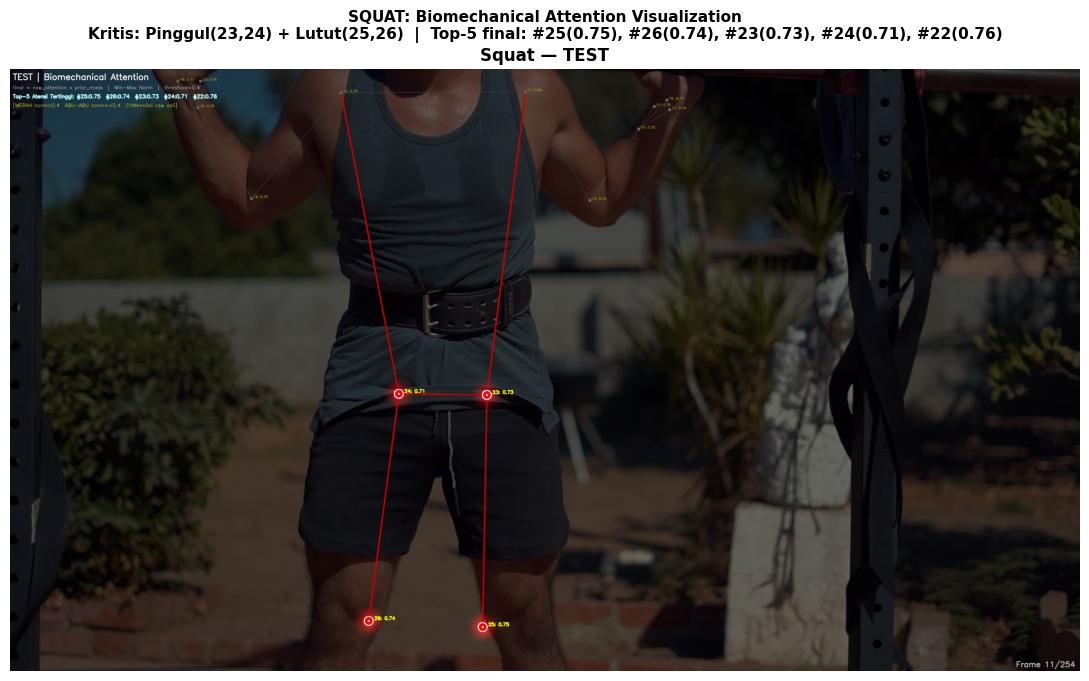

In [11]:
# ============================================================
# Eksekusi SQUAT
# Sendi kritis (1.0): Pinggul kiri/kanan (23, 24) + Lutut kiri/kanan (25, 26)
# Sendi lain   (0.1): 29 landmark sisanya
# ============================================================

squat_prior_mask = np.full(33, 0.1, dtype=np.float32)
for idx in [23, 24, 25, 26]:   # Pinggul (L/R) + Lutut (L/R)
    squat_prior_mask[idx] = 1.0

print("SQUAT — Exercise-Specific Spatial Prior Mask:")
print(f"  Sendi kritis (1.0) : Pinggul (23, 24) & Lutut (25, 26)")
print(f"  Sendi dasar  (0.1) : sisa 29 landmark")
print(f"  Efek: final_attention(kritis) = raw × 1.0  |  final_attention(lain) = raw × 0.1\n")

RAW_SQUAT_DIR = Path("../data/raw/Squat")
OUTPUT_DIR    = Path("../data/processed")

# Video test manual untuk sanity check fokus atensi squat frontal
SQUAT_TEST_VIDEO = Path("../data/test/5837700-uhd_3840_2160_24fps.mp4")


def _cari_video(folder: Path, keyword: str) -> "Path | None":
    """Cari .mp4 dengan keyword di nama file; prioritaskan file 'primer'."""
    candidates = sorted(folder.glob(f"*{keyword}*.mp4"))
    primer     = [p for p in candidates if "primer" in p.name]
    sekunder   = [p for p in candidates if "primer" not in p.name]
    ordered    = primer + sekunder
    return ordered[0] if ordered else None


# Prioritas utama: pakai video test manual jika tersedia.
# Jika file test tidak ada, fallback ke video raw squat seperti sebelumnya.
if SQUAT_TEST_VIDEO.exists():
    squat_videos = {"test": SQUAT_TEST_VIDEO}
    print(f"Video test manual dipakai untuk Squat: {SQUAT_TEST_VIDEO.name}")
else:
    squat_videos = {
        "frontal": _cari_video(RAW_SQUAT_DIR, "frontal"),
        "lateral": _cari_video(RAW_SQUAT_DIR, "lateral"),
    }
    print("Video test manual tidak ditemukan; fallback ke video raw Squat.")

print("Pencarian video Squat:")
for view, vpath in squat_videos.items():
    status = f"[OK]   {vpath.name}" if vpath else "[SKIP] tidak ditemukan"
    print(f"  {view.upper():8s}: {status}")

# ── Eksekusi Visualisasi ───────────────────────────────────────────────────────
squat_images = {}
for view, vpath in squat_videos.items():
    if vpath is None:
        print(f"\n[SKIP] Video Squat '{view}' tidak ditemukan di {RAW_SQUAT_DIR}")
        continue
    print(f"\n{'='*62}\nSquat {view.upper()} — {vpath.name}\n{'='*62}")
    out_video = OUTPUT_DIR / f"attention_squat_{view}.mp4"
    img_path  = render_biomechanical_attention(
        video_path          = str(vpath),
        output_path         = str(out_video),
        raw_attention       = raw_attention,
        exercise_prior_mask = squat_prior_mask,
    )
    if img_path:
        squat_images[view] = img_path

# ── Tampilkan Hasil ────────────────────────────────────────────────────────────
if squat_images:
    n    = len(squat_images)
    fig, axes = plt.subplots(1, n, figsize=(11 * n, 7))
    if n == 1:
        axes = [axes]
    for ax, (view, img_path) in zip(axes, squat_images.items()):
        ax.imshow(mpimg.imread(img_path))
        ax.set_title(f"Squat — {view.upper()}", fontsize=12, fontweight="bold")
        ax.axis("off")
    top5 = ", ".join(
        f"#{int(i)}({raw_attention[i]:.2f})"
        for i in np.argsort(raw_attention * squat_prior_mask)[::-1][:5]
    )
    fig.suptitle(
        "SQUAT: Biomechanical Attention Visualization\n"
        f"Kritis: Pinggul(23,24) + Lutut(25,26)  |  Top-5 final: {top5}",
        fontsize=11, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()
else:
    print("\n[PERINGATAN] Tidak ada output dihasilkan untuk Squat.")
    print("Pastikan file .mp4 tersedia di:", RAW_SQUAT_DIR)


## 4. Eksekusi DEADLIFT

Prior mask: **Bahu (11, 12)**, **Pinggul (23, 24)**, dan **Lutut (25, 26)** = 1.0 — rantai posterior untuk spine alignment dan hip-hinge.
Sendi lainnya diberi nilai dasar **0.1**.


DEADLIFT — Exercise-Specific Spatial Prior Mask:
  Sendi kritis (1.0) : Bahu (11, 12), Pinggul (23, 24) & Lutut (25, 26)
  Sendi dasar  (0.1) : sisa 27 landmark
  Efek: spine alignment + hip-hinge mendominasi visualisasi

Pencarian video Deadlift:
  FRONTAL   : [SKIP] tidak ditemukan
  LATERAL   : [OK]   primer_deadlift_lateral_subjek01_rep1.mp4

[SKIP] Video Deadlift 'frontal' tidak ditemukan di ..\data\raw\Deadlift

Deadlift LATERAL — primer_deadlift_lateral_subjek01_rep1.mp4
  raw_attention (sigmoid BSP) : min=0.6867, max=0.7583
  final_attention (×mask)     : min=0.0687, max=0.7521
  normalized (Min-Max)        : min=0.0000, max=1.0000
  Video: primer_deadlift_lateral_subjek01_rep1.mp4  |  1080×1920px  |  30.0 FPS  |  221 frame
  Total frame diproses : 221
  [TERSIMPAN] Video    : attention_deadlift_lateral.mp4
  [TERSIMPAN] Gambar   : attention_deadlift_lateral.jpg


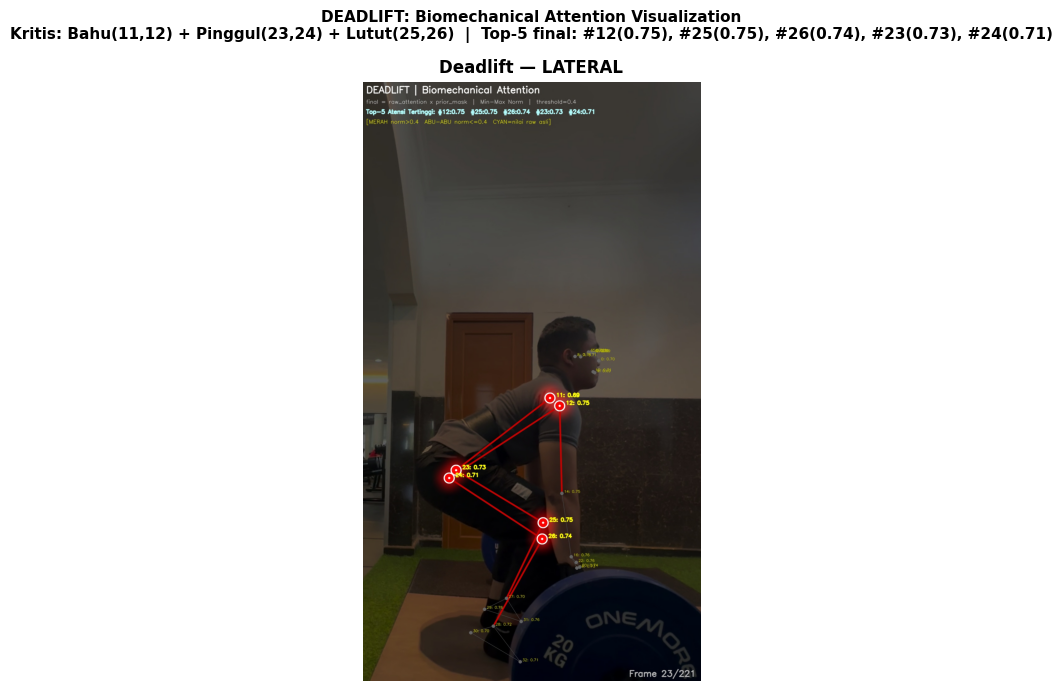

In [ ]:
# ============================================================
# Eksekusi DEADLIFT
# Sendi kritis (1.0): Bahu (11, 12) + Pinggul (23, 24) + Lutut (25, 26)
# Sendi lain   (0.1): 27 landmark sisanya
# ============================================================

deadlift_prior_mask = np.full(33, 0.1, dtype=np.float32)
for idx in [11, 12, 23, 24, 25, 26]:   # Bahu (L/R) + Pinggul (L/R) + Lutut (L/R)
    deadlift_prior_mask[idx] = 1.0

print("DEADLIFT — Exercise-Specific Spatial Prior Mask:")
print(f"  Sendi kritis (1.0) : Bahu (11, 12), Pinggul (23, 24) & Lutut (25, 26)")
print(f"  Sendi dasar  (0.1) : sisa 27 landmark")
print(f"  Efek: spine alignment + hip-hinge mendominasi visualisasi\n")

RAW_DEADLIFT_DIR = Path("../data/raw/Deadlift")
OUTPUT_DIR       = Path("../data/processed")

# Video test manual untuk sanity check fokus atensi deadlift
DEADLIFT_TEST_VIDEO = Path("../data/test/5837700-uhd_3840_2160_24fps.mp4")


def _cari_video(folder: Path, keyword: str) -> "Path | None":
    """Cari .mp4 dengan keyword di nama file; prioritaskan file 'primer'."""
    candidates = sorted(folder.glob(f"*{keyword}*.mp4"))
    primer     = [p for p in candidates if "primer" in p.name]
    sekunder   = [p for p in candidates if "primer" not in p.name]
    ordered    = primer + sekunder
    return ordered[0] if ordered else None


# Prioritas utama: pakai video test manual jika tersedia.
# Jika file test tidak ada, fallback ke video raw deadlift seperti sebelumnya.
if DEADLIFT_TEST_VIDEO.exists():
    deadlift_videos = {"test": DEADLIFT_TEST_VIDEO}
    print(f"Video test manual dipakai untuk Deadlift: {DEADLIFT_TEST_VIDEO.name}")
else:
    deadlift_videos = {
        "frontal": _cari_video(RAW_DEADLIFT_DIR, "frontal"),
        "lateral": _cari_video(RAW_DEADLIFT_DIR, "lateral"),
    }
    print("Video test manual tidak ditemukan; fallback ke video raw Deadlift.")

print("Pencarian video Deadlift:")
for view, vpath in deadlift_videos.items():
    status = f"[OK]   {vpath.name}" if vpath else "[SKIP] tidak ditemukan"
    print(f"  {view.upper():10s}: {status}")

# ── Eksekusi Visualisasi ───────────────────────────────────────────────────────
deadlift_images = {}
for view, vpath in deadlift_videos.items():
    if vpath is None:
        print(f"\n[SKIP] Video Deadlift '{view}' tidak ditemukan di {RAW_DEADLIFT_DIR}")
        continue
    print(f"\n{'='*62}\nDeadlift {view.upper()} — {vpath.name}\n{'='*62}")
    out_video = OUTPUT_DIR / f"attention_deadlift_{view}.mp4"
    img_path  = render_biomechanical_attention(
        video_path          = str(vpath),
        output_path         = str(out_video),
        raw_attention       = raw_attention,
        exercise_prior_mask = deadlift_prior_mask,
    )
    if img_path:
        deadlift_images[view] = img_path

# ── Tampilkan Hasil ────────────────────────────────────────────────────────────
if deadlift_images:
    n    = len(deadlift_images)
    fig, axes = plt.subplots(1, n, figsize=(11 * n, 7))
    if n == 1:
        axes = [axes]
    for ax, (view, img_path) in zip(axes, deadlift_images.items()):
        ax.imshow(mpimg.imread(img_path))
        ax.set_title(f"Deadlift — {view.upper()}", fontsize=12, fontweight="bold")
        ax.axis("off")
    top5 = ", ".join(
        f"#{int(i)}({raw_attention[i]:.2f})"
        for i in np.argsort(raw_attention * deadlift_prior_mask)[::-1][:5]
    )
    fig.suptitle(
        "DEADLIFT: Biomechanical Attention Visualization\n"
        f"Kritis: Bahu(11,12) + Pinggul(23,24) + Lutut(25,26)  |  Top-5 final: {top5}",
        fontsize=11, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()
else:
    print("\n[PERINGATAN] Tidak ada output dihasilkan untuk Deadlift.")
    print("Pastikan file .mp4 tersedia di:", RAW_DEADLIFT_DIR)


## 5. Eksekusi BENCH PRESS

Prior mask: **Bahu (11, 12)**, **Siku (13, 14)**, dan **Pergelangan Tangan (15, 16)** = 1.0 — rantai kinematik lengan untuk Elbow ROM.
Sendi lainnya diberi nilai dasar **0.1**.


BENCH PRESS — Exercise-Specific Spatial Prior Mask:
  Sendi kritis (1.0) : Bahu (11, 12), Siku (13, 14) & Pergelangan Tangan (15, 16)
  Sendi dasar  (0.1) : sisa 27 landmark
  Efek: rantai kinematik lengan (Elbow ROM) mendominasi visualisasi

Video test manual dipakai untuk Bench Press: WhatsApp Video 2026-07-15 at 02.21.57.mp4
Pencarian video Bench Press:
  TEST      : [OK]   WhatsApp Video 2026-07-15 at 02.21.57.mp4

Bench Press TEST — WhatsApp Video 2026-07-15 at 02.21.57.mp4
  raw_attention (sigmoid BSP) : min=0.6867, max=0.7583
  final_attention (×mask)     : min=0.0687, max=0.7569
  normalized (Min-Max)        : min=0.0000, max=1.0000
  Video: WhatsApp Video 2026-07-15 at 02.21.57.mp4  |  1280×720px  |  30.0 FPS  |  1019 frame
  Total frame diproses : 1019
  [TERSIMPAN] Video    : attention_benchpress_test.mp4
  [TERSIMPAN] Gambar   : attention_benchpress_test.jpg


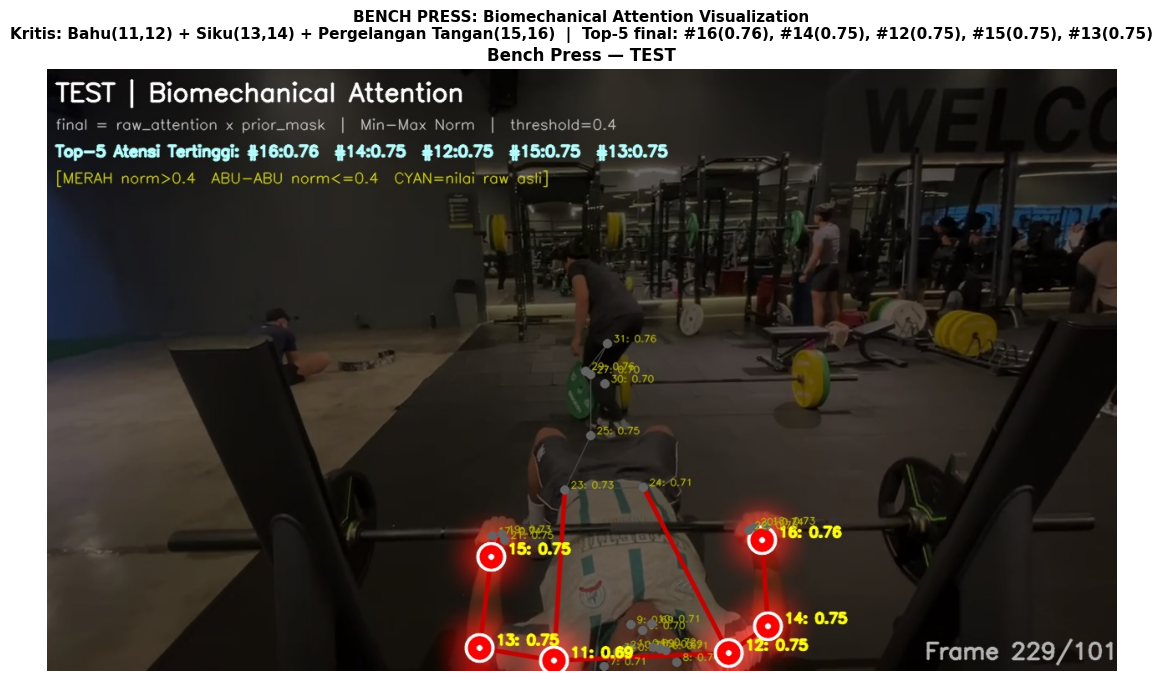

In [12]:
# ============================================================
# Eksekusi BENCH PRESS
# Sendi kritis (1.0): Bahu (11, 12) + Siku (13, 14) + Pergelangan Tangan (15, 16)
# Sendi lain   (0.1): 27 landmark sisanya
# ============================================================

benchpress_prior_mask = np.full(33, 0.1, dtype=np.float32)
for idx in [11, 12, 13, 14, 15, 16]:   # Bahu (L/R) + Siku (L/R) + Pergelangan Tangan (L/R)
    benchpress_prior_mask[idx] = 1.0

print("BENCH PRESS — Exercise-Specific Spatial Prior Mask:")
print(f"  Sendi kritis (1.0) : Bahu (11, 12), Siku (13, 14) & Pergelangan Tangan (15, 16)")
print(f"  Sendi dasar  (0.1) : sisa 27 landmark")
print(f"  Efek: rantai kinematik lengan (Elbow ROM) mendominasi visualisasi\n")

RAW_BENCH_DIR = Path("../data/raw/BenchPress")
OUTPUT_DIR    = Path("../data/processed")

# Video test manual untuk sanity check fokus atensi bench press
BENCH_TEST_VIDEO = Path("../data/test/WhatsApp Video 2026-07-15 at 02.21.57.mp4")


def _cari_video(folder: Path, keyword: str) -> "Path | None":
    """Cari .mp4 dengan keyword di nama file; prioritaskan file 'primer'."""
    candidates = sorted(folder.glob(f"*{keyword}*.mp4"))
    primer     = [p for p in candidates if "primer" in p.name]
    sekunder   = [p for p in candidates if "primer" not in p.name]
    ordered    = primer + sekunder
    return ordered[0] if ordered else None


# Prioritas utama: pakai video test manual jika tersedia.
# Jika file test tidak ada, fallback ke video raw bench press seperti sebelumnya.
if BENCH_TEST_VIDEO.exists():
    bench_videos = {"test": BENCH_TEST_VIDEO}
    print(f"Video test manual dipakai untuk Bench Press: {BENCH_TEST_VIDEO.name}")
else:
    bench_videos = {
        "frontal": _cari_video(RAW_BENCH_DIR, "frontal"),
        "lateral": _cari_video(RAW_BENCH_DIR, "lateral"),
    }
    print("Video test manual tidak ditemukan; fallback ke video raw Bench Press.")

print("Pencarian video Bench Press:")
for view, vpath in bench_videos.items():
    status = f"[OK]   {vpath.name}" if vpath else "[SKIP] tidak ditemukan"
    print(f"  {view.upper():10s}: {status}")

# ── Eksekusi Visualisasi ───────────────────────────────────────────────────────
bench_images = {}
for view, vpath in bench_videos.items():
    if vpath is None:
        print(f"\n[SKIP] Video Bench Press '{view}' tidak ditemukan di {RAW_BENCH_DIR}")
        continue
    print(f"\n{'='*62}\nBench Press {view.upper()} — {vpath.name}\n{'='*62}")
    out_video = OUTPUT_DIR / f"attention_benchpress_{view}.mp4"
    img_path  = render_biomechanical_attention(
        video_path          = str(vpath),
        output_path         = str(out_video),
        raw_attention       = raw_attention,
        exercise_prior_mask = benchpress_prior_mask,
    )
    if img_path:
        bench_images[view] = img_path

# ── Tampilkan Hasil ────────────────────────────────────────────────────────────
if bench_images:
    n    = len(bench_images)
    fig, axes = plt.subplots(1, n, figsize=(11 * n, 7))
    if n == 1:
        axes = [axes]
    for ax, (view, img_path) in zip(axes, bench_images.items()):
        ax.imshow(mpimg.imread(img_path))
        ax.set_title(f"Bench Press — {view.upper()}", fontsize=12, fontweight="bold")
        ax.axis("off")
    top5 = ", ".join(
        f"#{int(i)}({raw_attention[i]:.2f})"
        for i in np.argsort(raw_attention * benchpress_prior_mask)[::-1][:5]
    )
    fig.suptitle(
        "BENCH PRESS: Biomechanical Attention Visualization\n"
        f"Kritis: Bahu(11,12) + Siku(13,14) + Pergelangan Tangan(15,16)  |  Top-5 final: {top5}",
        fontsize=11, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()
else:
    print("\n[PERINGATAN] Tidak ada output dihasilkan untuk Bench Press.")
    print("Pastikan file .mp4 tersedia di:", RAW_BENCH_DIR)


## 6. Fungsi Pendukung: `draw_attention_skeleton()` & Pipeline Inferensi

Tiga fungsi yang menjadi tulang punggung perbandingan 5 model di sel berikutnya:

| Fungsi | Peran |
|---|---|
| `extract_attention_weights(model)` | Ekstrak array (33,) dari BSP jika ada; fallback seragam 0.5 untuk ablasi/baseline, lalu Min-Max Normalize ke [0, 1] |
| `build_inference_tensor(video_path)` | Baca video, ekstrak pose MediaPipe per-frame, kembalikan tensor `(1, 64, 33, 3)` siap inferensi |
| `draw_attention_skeleton(frame, landmarks, attention_weights)` | Overlay skeleton berbasis atensi: **MERAH** (atensi > threshold) vs **abu-abu** (atensi rendah) |

**Skema visual `draw_attention_skeleton()`:**

| `attention_weights[i]` | Warna sendi | Radius | Warna tulang |
|---|---|---|---|
| **> 0.4** (kritis) | 🔴 Merah terang `(0, 0, 255)` + Glow | 14 px | Merah tebal |
| **≤ 0.4** (non-kritis) | ⚫ Abu-abu redup `(80, 80, 80)` | 5 px | Abu-abu tipis |


In [8]:

# ============================================================
# 6. Fungsi Pendukung
#    (A) extract_attention_weights  — BSP → array (33,) ternormalisasi [0, 1]
#    (B) build_inference_tensor     — video → tensor (1, 64, 33, 3)
#    (C) draw_attention_skeleton    — frame + landmark → overlay OpenCV
# ============================================================


# ── (A) Ekstraksi bobot atensi dari model ─────────────────────────────────────
def extract_attention_weights(mdl: "AttentiveSkel3D") -> np.ndarray:
    """
    Ekstrak array bobot atensi (33,) dari model yang sudah dimuat.

    Jika model memiliki layer biomechanical_spatial_prior (Full Model / Ablasi B / Ablasi C):
      → sigmoid(BSP) di-flatten menjadi array float32 (33,)
    Jika tidak ada BSP (Baseline 3D-CNN / Ablasi A — Tanpa Prior):
      → Kembalikan array seragam 0.5 agar visualisasi tetap bisa berjalan.

    Nilai dikembalikan sudah ternormalisasi ke [0, 1] via Min-Max Scaling.
    """
    mdl.eval()
    with torch.no_grad():
        if hasattr(mdl, "biomechanical_spatial_prior"):
            bsp_raw = mdl.biomechanical_spatial_prior           # (1, 1, 1, 33, 1)
            weights = torch.sigmoid(bsp_raw).squeeze().cpu().numpy().astype(np.float32)
        else:
            # Tidak ada BSP → bobot seragam sebagai penanda "model buta spasial"
            weights = np.full(33, 0.5, dtype=np.float32)

    # Min-Max Normalization → [0, 1]
    w_min, w_max = weights.min(), weights.max()
    if w_max - w_min > 1e-8:
        weights = (weights - w_min) / (w_max - w_min)
    return weights


# ── (B) Bangun tensor inferensi dari video ────────────────────────────────────
def build_inference_tensor(
    video_path: str,
    max_frames: int = 64,
) -> "tuple[torch.Tensor | None, list]":
    """
    Baca video, ekstrak pose MediaPipe per-frame, kembalikan:
      - tensor    : torch.Tensor shape (1, max_frames, 33, 3) siap dimasukkan ke model
      - lm_frames : list of list — objek landmark MediaPipe per-frame (untuk visualisasi)

    Jika tidak ada frame valid, kembalikan (None, []).
    Jika frame < max_frames, padding dilakukan dengan frame terakhir.
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f"  [ERROR] Tidak bisa membuka video: {video_path}")
        return None, []

    sequence: list  = []   # list of np.ndarray (33, 3)
    lm_frames: list = []   # list of MediaPipe landmark objects

    with mp_pose.Pose(
        model_complexity=1,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.5,
    ) as pose:
        while cap.isOpened():
            ret, frame_bgr = cap.read()
            if not ret:
                break
            frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
            result    = pose.process(frame_rgb)
            if result.pose_landmarks is None:
                continue
            lms    = result.pose_landmarks.landmark
            coords = np.array(
                [[lm.x, lm.y, lm.z] for lm in lms],
                dtype=np.float32,
            )  # (33, 3)
            sequence.append(coords)
            lm_frames.append(lms)

    cap.release()

    if len(sequence) == 0:
        print("  [PERINGATAN] Tidak ada pose terdeteksi di video.")
        return None, []

    total = len(sequence)
    if total >= max_frames:
        # Sampel max_frames frame terdistribusi rata
        indices   = np.linspace(0, total - 1, max_frames, dtype=int)
        sequence  = [sequence[i] for i in indices]
        lm_frames = [lm_frames[i] for i in indices]
    else:
        # Padding dengan frame terakhir jika video lebih pendek dari 64 frame
        pad       = max_frames - total
        sequence  = sequence  + [sequence[-1]]  * pad
        lm_frames = lm_frames + [lm_frames[-1]] * pad

    tensor = torch.tensor(
        np.stack(sequence, axis=0),  # (max_frames, 33, 3)
        dtype=torch.float32,
    ).unsqueeze(0)  # → (1, max_frames, 33, 3)

    return tensor, lm_frames


# ── (C) Fungsi visualisasi skeleton dengan atensi ─────────────────────────────
def draw_attention_skeleton(
    frame: np.ndarray,
    landmarks,                          # list of MediaPipe landmark objects
    attention_weights: np.ndarray,      # (33,) float32, sudah ternormalisasi [0,1]
    threshold: float = 0.4,
) -> np.ndarray:
    """
    Gambar overlay skeleton berbasis atensi pada satu frame BGR.

    Aturan warna sendi:
      attention_weights[i] > threshold  →  MERAH TERANG  (BGR: 0, 0, 255) radius 14 px + Glow
      attention_weights[i] ≤ threshold  →  ABU-ABU REDUP (BGR: 80, 80, 80) radius  5 px

    Aturan warna tulang (garis antar sendi):
      Rata-rata kedua ujung > threshold  →  Merah tebal  (lebar 3 px)
      Sebaliknya                         →  Abu-abu tipis (lebar 1 px)

    Label teks nilai atensi per sendi ditampilkan dalam warna CYAN.
    """
    out  = frame.copy()
    h, w = out.shape[:2]
    n_lm = min(33, len(landmarks))

    # Konstanta visual
    COLOR_KRITIS  = (0,   0, 255)   # BGR — Merah terang (sendi kritis)
    COLOR_NON     = (80,  80,  80)  # BGR — Abu-abu redup (sendi non-kritis)
    COLOR_BONE_HI = (0,   0, 200)   # BGR — Merah untuk tulang kritis
    COLOR_BONE_LO = (50,  50,  50)  # BGR — Abu-abu sangat redup untuk tulang non-kritis
    RADIUS_HI     = 14
    RADIUS_LO     = 5

    # Gelapkan background supaya overlay lebih kontras
    out = (out.astype(np.float32) * 0.45).astype(np.uint8)

    # ── Pass 1: Efek Glow melingkari sendi kritis ──────────────────────────────
    glow_layer = np.zeros_like(out)
    for i in range(n_lm):
        lm = landmarks[i]
        if getattr(lm, "visibility", 1.0) < 0.3:
            continue
        if attention_weights[i] > threshold:
            px = int(lm.x * w)
            py = int(lm.y * h)
            cv2.circle(glow_layer, (px, py), RADIUS_HI + 18, COLOR_KRITIS, -1)
    glow_blur = cv2.GaussianBlur(glow_layer, (51, 51), 20)
    out       = cv2.addWeighted(out, 1.0, glow_blur, 0.55, 0)

    # ── Pass 2: Garis tulang (koneksi BlazePose standar) ──────────────────────
    for connection in mp_pose.POSE_CONNECTIONS:
        s_idx, e_idx = connection
        if s_idx >= n_lm or e_idx >= n_lm:
            continue
        lm_s = landmarks[s_idx]
        lm_e = landmarks[e_idx]
        if getattr(lm_s, "visibility", 1.0) < 0.3 or getattr(lm_e, "visibility", 1.0) < 0.3:
            continue
        x1 = int(lm_s.x * w);  y1 = int(lm_s.y * h)
        x2 = int(lm_e.x * w);  y2 = int(lm_e.y * h)
        avg_w = (attention_weights[s_idx] + attention_weights[e_idx]) / 2.0
        if avg_w > threshold:
            cv2.line(out, (x1, y1), (x2, y2), COLOR_BONE_HI, 3, cv2.LINE_AA)
        else:
            cv2.line(out, (x1, y1), (x2, y2), COLOR_BONE_LO, 1, cv2.LINE_AA)

    # ── Pass 3: Titik sendi + label nilai atensi ──────────────────────────────
    for i in range(n_lm):
        lm = landmarks[i]
        if getattr(lm, "visibility", 1.0) < 0.3:
            continue
        px = int(lm.x * w)
        py = int(lm.y * h)
        if attention_weights[i] > threshold:
            # MERAH TERANG — sendi kritis
            cv2.circle(out, (px, py), RADIUS_HI, COLOR_KRITIS, -1, cv2.LINE_AA)
            cv2.circle(out, (px, py), RADIUS_HI, (255, 255, 255), 2, cv2.LINE_AA)
            cv2.circle(out, (px, py), 3,         (255, 255, 255), -1, cv2.LINE_AA)
            cv2.putText(
                out, f"{i}:{attention_weights[i]:.2f}",
                (px + RADIUS_HI + 4, py - 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.52,
                (0, 255, 255), 2, cv2.LINE_AA,
            )
        else:
            # ABU-ABU REDUP — sendi non-kritis
            cv2.circle(out, (px, py), RADIUS_LO, COLOR_NON, -1, cv2.LINE_AA)
            cv2.putText(
                out, f"{i}:{attention_weights[i]:.2f}",
                (px + RADIUS_LO + 2, py - 2),
                cv2.FONT_HERSHEY_SIMPLEX, 0.35,
                (0, 160, 160), 1, cv2.LINE_AA,
            )

    return out


print("Fungsi pendukung berhasil didefinisikan:")
print("  ✔ extract_attention_weights(model)             → array (33,) ternormalisasi [0, 1]")
print("  ✔ build_inference_tensor(video_path)           → tensor (1, 64, 33, 3)")
print("  ✔ draw_attention_skeleton(frame, lm, weights) → frame BGR beranotasi")


Fungsi pendukung berhasil didefinisikan:
  ✔ extract_attention_weights(model)             → array (33,) ternormalisasi [0, 1]
  ✔ build_inference_tensor(video_path)           → tensor (1, 64, 33, 3)
  ✔ draw_attention_skeleton(frame, lm, weights) → frame BGR beranotasi


## 7. Perbandingan Visualisasi Atensi — 5 Skenario Model

Sel ini memuat **satu video uji yang sama** lalu meloopnya ke kelima checkpoint model, kemudian:
1. Menjalankan inferensi → prediksi *Form Benar / Form Salah* + confidence.
2. Mengekstrak bobot atensi (33 sendi) via `extract_attention_weights()`.
3. Menggambar overlay skeleton berbasis atensi pada satu frame representatif.
4. Menyimpan gambar ke `data/processed/comparison_attention/` dan menampilkan grid perbandingan.

> **Cara membaca grid hasil**: Model dengan atensi lebih *selektif* (MERAH hanya di sendi yang relevan, abu-abu di sendi tidak relevan) menunjukkan *inductive bias* biomekanikal yang lebih kuat dan terstruktur.


Video yang akan diproses:
  1. ..\data\test\5837700-uhd_3840_2160_24fps.mp4
  2. ..\data\test\WhatsApp Video 2026-07-15 at 02.21.57.mp4

VIDEO UJI : 5837700-uhd_3840_2160_24fps.mp4
OUTPUT    : ..\data\processed\comparison_attention\5837700_uhd_3840_2160_24fps
Ekstraksi pose dari video uji...
  Tensor input siap    : (1, 64, 33, 3)
  Total frame diparsing: 64
  Frame representatif  : frame ke-127 dari 254 total frame

──────────────────────────────────────────────────────────────
  Model : Baseline 3D-CNN
  Path  : baseline_3dcnn_model.pth
  Missing keys (strict=False OK) : 6 key(s)
  Prediksi  : Form SALAH ✗  (confidence: 53.9%)
  BSP layer : Ya (BSP tersedia)
  Top-3 atensi sendi: #32:0.73  #15:0.73  #1:0.73
  [TERSIMPAN] attn_Baseline_3D-CNN.jpg

──────────────────────────────────────────────────────────────
  Model : Ablasi A — Tanpa Prior
  Path  : ablasi_a_no_prior.pth
  Missing keys (strict=False OK) : 1 key(s)
  Prediksi  : Form SALAH ✗  (confidence: 85.9%)
  BSP layer : Ya (BSP

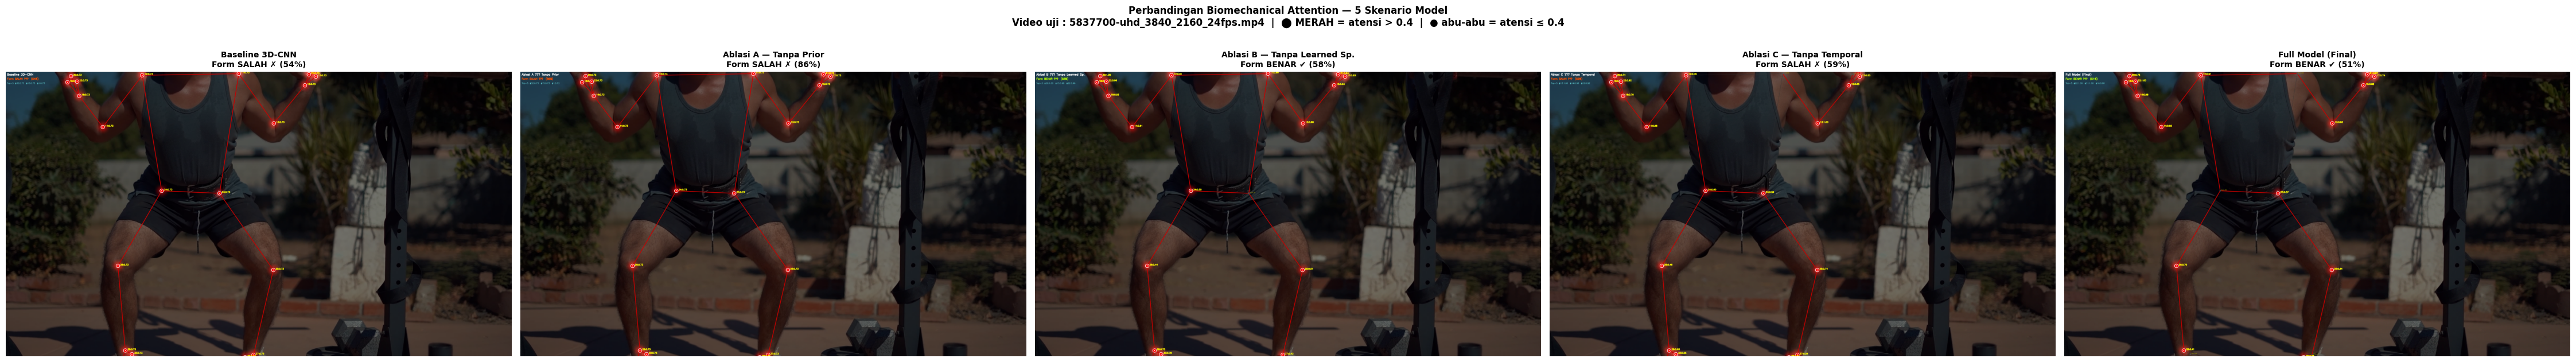


Grid perbandingan tersimpan : ..\data\processed\comparison_attention\5837700_uhd_3840_2160_24fps\comparison_grid.jpg

  TABEL KOMPARASI BOBOT ATENSI — SENDI UTAMA LATIHAN BEBAN


,Baseline 3D-CNN,Ablasi A — Tanpa Prior,Ablasi B — Tanpa Learned Sp.,Ablasi C — Tanpa Temporal,Full Model (Final)
Sendi,,,,,
Bahu Kiri,0.731,0.731,0.598,0.000,0.053
Bahu Kanan,0.731,0.731,0.910,0.792,0.912
Siku Kiri,0.731,0.731,0.978,1.000,0.832
Siku Kanan,0.731,0.731,0.911,0.982,0.919
Pinggul Kiri,0.731,0.731,0.392,0.587,0.571
Pinggul Kanan,0.731,0.731,0.498,0.605,0.354
Lutut Kiri,0.731,0.731,0.506,0.741,0.843
Lutut Kanan,0.731,0.731,0.438,0.463,0.703
Pergelangan Kaki Kiri,0.731,0.731,0.425,0.541,0.229



VIDEO UJI : WhatsApp Video 2026-07-15 at 02.21.57.mp4
OUTPUT    : ..\data\processed\comparison_attention\WhatsApp_Video_2026_07_15_at_02_21_57
Ekstraksi pose dari video uji...


e:\Software-IF\DevTools\Anaconda\envs\attentiveskel310\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


  Tensor input siap    : (1, 64, 33, 3)
  Total frame diparsing: 64
  Frame representatif  : frame ke-509 dari 1019 total frame

──────────────────────────────────────────────────────────────
  Model : Baseline 3D-CNN
  Path  : baseline_3dcnn_model.pth
  Missing keys (strict=False OK) : 6 key(s)
  Prediksi  : Form SALAH ✗  (confidence: 55.5%)
  BSP layer : Ya (BSP tersedia)
  Top-3 atensi sendi: #32:0.73  #15:0.73  #1:0.73
  [TERSIMPAN] attn_Baseline_3D-CNN.jpg

──────────────────────────────────────────────────────────────
  Model : Ablasi A — Tanpa Prior
  Path  : ablasi_a_no_prior.pth
  Missing keys (strict=False OK) : 1 key(s)
  Prediksi  : Form SALAH ✗  (confidence: 98.2%)
  BSP layer : Ya (BSP tersedia)
  Top-3 atensi sendi: #32:0.73  #15:0.73  #1:0.73
  [TERSIMPAN] attn_Ablasi_A__Tanpa_Prior.jpg

──────────────────────────────────────────────────────────────
  Model : Ablasi B — Tanpa Learned Sp.
  Path  : ablasi_b_no_learned.pth
  Missing keys (strict=False OK) : 4 key(s)
  Pre

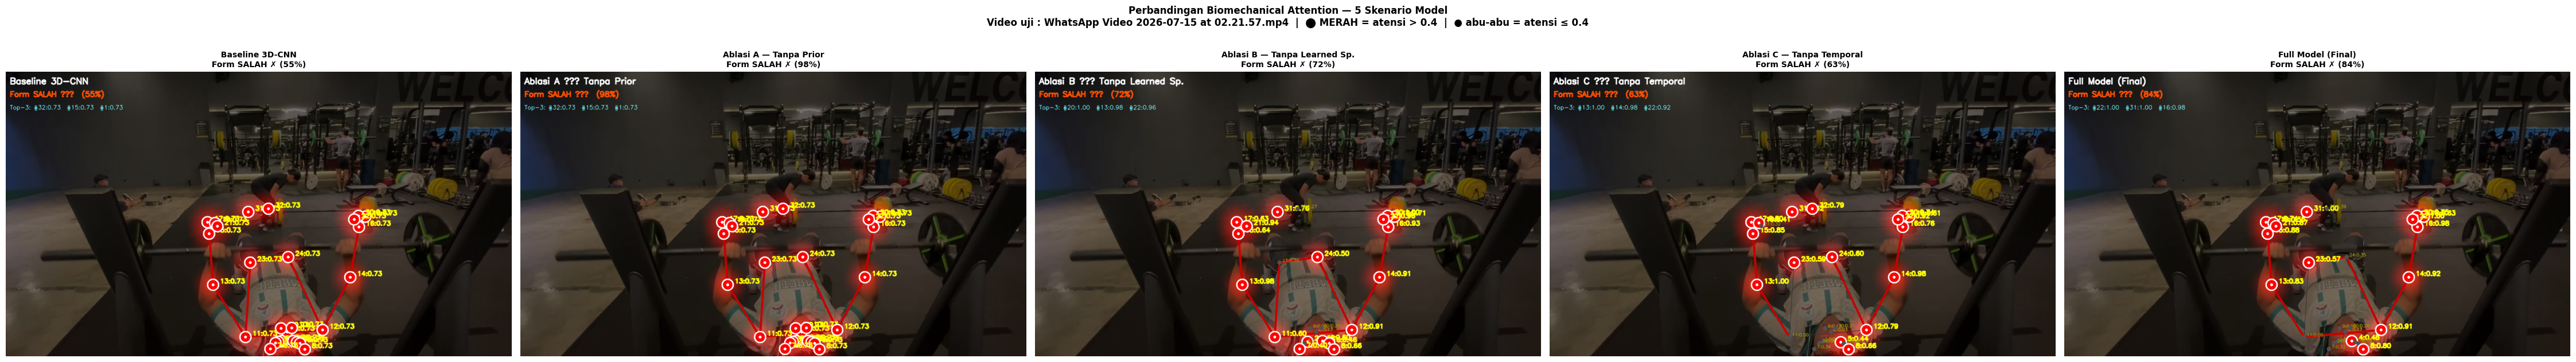


Grid perbandingan tersimpan : ..\data\processed\comparison_attention\WhatsApp_Video_2026_07_15_at_02_21_57\comparison_grid.jpg

  TABEL KOMPARASI BOBOT ATENSI — SENDI UTAMA LATIHAN BEBAN


,Baseline 3D-CNN,Ablasi A — Tanpa Prior,Ablasi B — Tanpa Learned Sp.,Ablasi C — Tanpa Temporal,Full Model (Final)
Sendi,,,,,
Bahu Kiri,0.731,0.731,0.598,0.000,0.053
Bahu Kanan,0.731,0.731,0.910,0.792,0.912
Siku Kiri,0.731,0.731,0.978,1.000,0.832
Siku Kanan,0.731,0.731,0.911,0.982,0.919
Pinggul Kiri,0.731,0.731,0.392,0.587,0.571
Pinggul Kanan,0.731,0.731,0.498,0.605,0.354
Lutut Kiri,0.731,0.731,0.506,0.741,0.843
Lutut Kanan,0.731,0.731,0.438,0.463,0.703
Pergelangan Kaki Kiri,0.731,0.731,0.425,0.541,0.229


In [ ]:
# ============================================================
# 7. Perbandingan Visualisasi Atensi — 5 Skenario Model
#    Multi-video test: setiap video uji → 5 model → 5 gambar overlay
# ============================================================

# ── Daftar video test manual yang ingin dicoba ─────────────────────────────────
CUSTOM_TEST_VIDEOS = [
    Path("../data/test/5837700-uhd_3840_2160_24fps.mp4"),
    Path("../data/test/WhatsApp Video 2026-07-15 at 02.21.57.mp4"),
]

# Jika video test manual tidak ada, fallback ke video dari data/raw seperti sebelumnya
FALLBACK_RAW_DIRS = [
    Path("../data/raw/Squat"),
    Path("../data/raw/Deadlift"),
    Path("../data/raw/BenchPress"),
]

MODEL_SCENARIOS = [
    ("Baseline 3D-CNN",              Path("../models/saved_models/baseline_3dcnn_model.pth")),
    ("Ablasi A — Tanpa Prior",       Path("../models/saved_models/ablasi_a_no_prior.pth")),
    ("Ablasi B — Tanpa Learned Sp.", Path("../models/saved_models/ablasi_b_no_learned.pth")),
    ("Ablasi C — Tanpa Temporal",    Path("../models/saved_models/ablasi_c_no_temporal.pth")),
    ("Full Model (Final)",           Path("../models/saved_models/AttentiveSkel3D_Final.pth")),
]
CLASS_NAMES = {0: "Form BENAR ✔", 1: "Form SALAH ✗"}

OUTPUT_COMP = Path("../data/processed/comparison_attention")
OUTPUT_COMP.mkdir(parents=True, exist_ok=True)


def _sanitize_name(path_obj: Path) -> str:
    return (
        path_obj.stem
        .replace(" ", "_")
        .replace("—", "")
        .replace("-", "_")
        .replace(".", "_")
        .replace("/", "_")
    )


def _collect_test_videos() -> list[Path]:
    selected = [video_path for video_path in CUSTOM_TEST_VIDEOS if video_path.exists()]
    if selected:
        return selected

    print("[INFO] Video test manual tidak ditemukan. Menggunakan fallback dari data/raw/.")
    fallback_videos: list[Path] = []
    for directory in FALLBACK_RAW_DIRS:
        found = sorted(directory.glob("*.mp4"))
        if found:
            fallback_videos.append(found[0])
    return fallback_videos


def _run_attention_comparison_for_video(test_video_path: Path) -> None:
    case_name = _sanitize_name(test_video_path)
    case_dir = OUTPUT_COMP / case_name
    case_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n{'=' * 74}")
    print(f"VIDEO UJI : {test_video_path.name}")
    print(f"OUTPUT    : {case_dir}")
    print(f"{'=' * 74}")

    print("Ekstraksi pose dari video uji...")
    tensor_input, lm_frames = build_inference_tensor(str(test_video_path), max_frames=64)

    if tensor_input is None or len(lm_frames) == 0:
        raise RuntimeError(
            f"Gagal mengekstrak pose dari video: {test_video_path.name}. "
            "Pastikan MediaPipe bisa mendeteksi pose pada video tersebut."
        )

    print(f"  Tensor input siap    : {tuple(tensor_input.shape)}")
    print(f"  Total frame diparsing: {len(lm_frames)}")

    _mid_idx = len(lm_frames) // 2
    _cap = cv2.VideoCapture(str(test_video_path))
    _total_raw = int(_cap.get(cv2.CAP_PROP_FRAME_COUNT))
    _cap.set(cv2.CAP_PROP_POS_FRAMES, max(0, _total_raw // 2))
    _ret, _raw_frame = _cap.read()
    _cap.release()

    if not _ret:
        _raw_frame = np.zeros((480, 640, 3), dtype=np.uint8)
        print("  [PERINGATAN] Tidak bisa membaca frame representatif — pakai frame hitam.")
    else:
        print(f"  Frame representatif  : frame ke-{_total_raw // 2} dari {_total_raw} total frame\n")

    lm_representative = lm_frames[_mid_idx]

    attention_summary = {}
    result_images = []
    result_titles = []
    result_metadata = []

    for scenario_label, model_path in MODEL_SCENARIOS:
        print(f"{'─' * 62}")
        print(f"  Model : {scenario_label}")
        print(f"  Path  : {model_path.name}")

        if not model_path.exists():
            print("  [SKIP] File checkpoint tidak ditemukan.\n")
            placeholder = np.zeros_like(_raw_frame)
            cv2.putText(
                placeholder,
                "FILE TIDAK DITEMUKAN",
                (10, placeholder.shape[0] // 2),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.7,
                (0, 0, 200),
                2,
                cv2.LINE_AA,
            )
            result_images.append(cv2.cvtColor(placeholder, cv2.COLOR_BGR2RGB))
            result_titles.append(scenario_label)
            result_metadata.append("FILE TIDAK DITEMUKAN")
            continue

        _model = AttentiveSkel3D(num_classes=2)
        _chk = torch.load(str(model_path), map_location="cpu", weights_only=True)

        if isinstance(_chk, dict):
            _sd = _chk.get("model_state_dict") or _chk.get("state_dict") or _chk
        else:
            _sd = _chk

        _incompat = _model.load_state_dict(_sd, strict=False)
        _model.eval()

        _missing = list(getattr(_incompat, "missing_keys", []))
        if _missing:
            print(f"  Missing keys (strict=False OK) : {len(_missing)} key(s)")

        with torch.no_grad():
            _logits = _model(tensor_input)
            _probs = torch.softmax(_logits, dim=-1)
            _pred = int(_logits.argmax(dim=-1).item())
            _conf = float(_probs[0, _pred].item()) * 100.0

        pred_text = CLASS_NAMES.get(_pred, f"Kelas {_pred}")
        print(f"  Prediksi  : {pred_text}  (confidence: {_conf:.1f}%)")

        attn_w = extract_attention_weights(_model)
        attention_summary[scenario_label] = attn_w

        top3_str = "  ".join(
            f"#{int(i)}:{attn_w[i]:.2f}"
            for i in np.argsort(attn_w)[::-1][:3]
        )
        has_bsp = "Ya (BSP tersedia)" if hasattr(_model, "biomechanical_spatial_prior") else "Tidak (seragam 0.5)"
        print(f"  BSP layer : {has_bsp}")
        print(f"  Top-3 atensi sendi: {top3_str}")

        annotated = draw_attention_skeleton(
            frame=_raw_frame,
            landmarks=lm_representative,
            attention_weights=attn_w,
            threshold=0.4,
        )

        cv2.putText(
            annotated,
            scenario_label,
            (10, 32),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.72,
            (255, 255, 255),
            2,
            cv2.LINE_AA,
        )
        pred_color = (0, 255, 180) if _pred == 0 else (0, 80, 255)
        cv2.putText(
            annotated,
            f"{pred_text}  ({_conf:.0f}%)",
            (10, 64),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.62,
            pred_color,
            2,
            cv2.LINE_AA,
        )
        cv2.putText(
            annotated,
            f"Top-3: {top3_str}",
            (10, 96),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.48,
            (255, 255, 120),
            1,
            cv2.LINE_AA,
        )

        safe_name = (
            scenario_label
            .replace(" ", "_")
            .replace("—", "")
            .replace(".", "")
            .replace("/", "")
        )
        save_path = case_dir / f"attn_{safe_name}.jpg"
        cv2.imwrite(str(save_path), annotated)
        print(f"  [TERSIMPAN] {save_path.name}\n")

        result_images.append(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        result_titles.append(scenario_label)
        result_metadata.append(f"{pred_text} ({_conf:.0f}%)")

    n_models = len(result_images)
    if n_models > 0:
        fig, axes = plt.subplots(1, n_models, figsize=(9 * n_models, 7))
        if n_models == 1:
            axes = [axes]
        for ax, img, title, meta in zip(axes, result_images, result_titles, result_metadata):
            ax.imshow(img)
            ax.set_title(f"{title}\n{meta}", fontsize=10, fontweight="bold")
            ax.axis("off")
        fig.suptitle(
            "Perbandingan Biomechanical Attention — 5 Skenario Model\n"
            f"Video uji : {test_video_path.name}  |  "
            "⬤ MERAH = atensi > 0.4  |  ● abu-abu = atensi ≤ 0.4",
            fontsize=12,
            fontweight="bold",
        )
        plt.tight_layout()
        grid_path = case_dir / "comparison_grid.jpg"
        plt.savefig(str(grid_path), dpi=150, bbox_inches="tight")
        plt.show()
        print(f"\nGrid perbandingan tersimpan : {grid_path}")
    else:
        print("[PERINGATAN] Tidak ada gambar yang dihasilkan.")

    if attention_summary:
        KEY_JOINTS = {
            11: "Bahu Kiri",
            12: "Bahu Kanan",
            13: "Siku Kiri",
            14: "Siku Kanan",
            23: "Pinggul Kiri",
            24: "Pinggul Kanan",
            25: "Lutut Kiri",
            26: "Lutut Kanan",
            27: "Pergelangan Kaki Kiri",
            28: "Pergelangan Kaki Kanan",
        }

        df_attn = pd.DataFrame(
            {
                label: {
                    KEY_JOINTS[idx]: round(float(weights[idx]), 3)
                    for idx in KEY_JOINTS
                    if idx < len(weights)
                }
                for label, weights in attention_summary.items()
            }
        )
        df_attn.index.name = "Sendi"

        print("\n" + "=" * 62)
        print("  TABEL KOMPARASI BOBOT ATENSI — SENDI UTAMA LATIHAN BEBAN")
        print("=" * 62)

        display(
            df_attn.style
            .background_gradient(cmap="Reds", axis=None)
            .format("{:.3f}")
            .set_caption(
                "Bobot Atensi per Sendi (0.0 – 1.0)  |  "
                "Merah gelap = atensi tinggi  |  Putih = atensi rendah"
            )
            .set_table_styles([
                {"selector": "caption", "props": [("font-size", "13px"), ("font-weight", "bold"), ("padding", "8px")]},
                {"selector": "th", "props": [("font-size", "11px"), ("text-align", "center"), ("padding", "6px")]},
                {"selector": "td", "props": [("font-size", "11px"), ("text-align", "center"), ("padding", "6px")]},
            ])
        )


# ── Jalankan untuk dua video test manual jika tersedia ─────────────────────────
selected_test_videos = _collect_test_videos()

if not selected_test_videos:
    raise FileNotFoundError(
        "Tidak ada video test manual di data/test/ dan tidak ada fallback video di data/raw/."
    )

print("Video yang akan diproses:")
for idx, video_path in enumerate(selected_test_videos, start=1):
    print(f"  {idx}. {video_path}")

for video_path in selected_test_videos:
    _run_attention_comparison_for_video(video_path)
